# Stage 2 – Final Modeling Notebook

## 1. Notebook Title & Introduction


## 2. Load Libraries & Dataset

#### 2.1 Import Libraries

#### 2.2 Load Final Data


## 3.Initial Checks

#### 3.1 Check for Missing Values

#### 3.2 Show Shape and Columns

#### 3.3 Check Class Balance for Labels


## 4. Prepare Features (X) and Targets (y)

#### 4.1 Split Features and Labels


## 5. Baseline Model: Logistic Regression

#### 5.1 Define Helper Function (train_and_evaluate_model) for Training and Evaluation (Helper Fuction 1)

#### 5.2 Bias and Fairness Analysis: Gender-Based Evaluation (Helper Fuction 2)

#### 5.3 Hyperparameter Optimization using GridSearchCV with Cross-Validation (Helper Function 3)

#### 5.4 Save Final Model Metrics for Comparison Table & Plot (Helper Function 4)

#### 5.5 Scale features only for Logistic Regression

#### 5.6 Hyperparameter Tuning for Logistic Regression

#### 5.7 Train and Evaluate Logistic Regression (Model 1)

#### 5.8 Gender Bias Evaluation for Logistic Regression


## 6. Random Forest (Model 2)

#### 6.1 Hyperparameter Tuning for Random Forest

#### 6.2 Train and Evaluate Random Forest (Model 2)

#### 6.3 Gender Bias Evaluation for Random Forest


## 7. Gradient Boosting (Model 3)

#### 7.1 Hyperparameter Tuning for Gradient Boosting

#### 7.2 Train and Evaluate Gradient Boosting (Model 3)

#### 7.3 Gender Bias Evaluation for Gradient Boosting


## 8. CatBoost (Model 4)

#### 8.1 Hyperparameter Tuning for CatBoost

#### 8.2 Train and Evaluate CatBoost (Model 4)

#### 8.3 Gender Bias Evaluation for CatBoost


## 9. Choose The Best Model

#### 9.1 Compare Final Models

#### 9.2 Comparing Gender Bias in Model Performance (Class 0 vs Class 1)

#### 9.3 Final SHAP-Based Interpretation of the Best Model (Gradient Boosting)


# 1. Notebook Title & Introduction

### ADHD Classification – Final Modeling Notebook.

My notebook describes the final model of the ADHD classification project.
My aim is to project the likelihood of the participant being diagnosed with ADHD, based on their socio-demographic information, parenting styles, and functional brain connectome.

**Objectives**
- Create models to classify ADHD's prediction.
- Use standard metrics to assess their performance(accuracy, precision, recall, F1-score)
- Make sure there’s fairness, in particular for gender groups, since AAHD underdiagnosed more in females.
- Using SHAP to support clinical understanding, provide interpretable results.
- Pick a model that can be used in health care.

 **I use these models to be tested:**
1. Use **logistic regression** which is baseline interpretable
2. **Random Forest** is a very common and robust model.
3. **Gradient Boosting** (sklearn) is a boosting technique to offer strong performance while being easily interpretable.

4. **CatBoostClassifier** : I used CatBoostClassifier, a powerful gradient boosting model that handles categorical features natively and provides strong performance with good interpretability. 

The modeling phase follows best practice from data science and machine learning to ensure proper data splitting, no leakage, bias assessment, and GDPR-compliant interpretability. 


# 2. Load Libraries & Dataset

### 2.1 Import Libraries

In [2]:
#  These libraries should be useful, so I must import them.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML



# My machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier


# Preprocessing and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)


#  Explainability
import shap

#  Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully")



 All libraries imported successfully


### 2.2 Load Final Data

In [4]:
# I'm writing to load the final processed train and test sets
train_df = pd.read_csv("../final_data/final_train_dataset.csv")
test_df = pd.read_csv("../final_data/final_test_dataset.csv")

# My final_data basic shape info
print(" Train shape:", train_df.shape)
print(" Test shape:", test_df.shape)

#  Quick preview
train_df.head()


 Train shape: (970, 48)
 Test shape: (243, 48)


,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Externalizing,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Emotional_Problems,APQ_P_APQ_P_ID,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Internalizing,APQ_P_APQ_P_INV,...,connectome_PC23,connectome_PC24,connectome_PC25,connectome_PC26,connectome_PC27,connectome_PC28,connectome_PC29,connectome_PC30,ADHD_Outcome,Sex_F
0,8.0,8.0,18.0,7.0,0.0,6.0,13.0,4.0,10.0,34.0,...,-0.001408,0.006617,0.002862,-0.001641,0.004266,-0.001695,-0.005337,0.004339,1,0
1,7.0,8.0,14.0,5.0,1.0,2.0,10.0,4.0,6.0,35.0,...,0.009077,0.000722,-0.001884,-0.005270,0.001582,0.003384,0.008372,0.005071,1,0
2,10.0,16.0,24.0,9.0,6.0,4.0,12.0,4.0,8.0,39.0,...,-0.003477,0.001931,0.002171,-0.004555,-0.001578,-0.001482,0.001844,-0.000159,1,1
3,10.0,11.0,18.0,4.0,1.0,4.0,15.0,3.0,7.0,40.0,...,0.000333,0.000086,-0.003923,-0.003587,-0.002241,0.005052,-0.002403,0.005747,1,1
4,8.0,12.0,17.0,9.0,4.0,0.0,12.0,5.0,5.0,35.0,...,0.003384,-0.001011,0.005669,-0.002668,-0.001047,0.001881,-0.001560,-0.000008,1,0


### Description of load libraries and dataset: 

I loaded the final training and test datasets, which were cleaned, imputed, and feature-selected in Notebook 1.
These datasets were split using participant IDs to avoid data leakage and ensure consistent structure across all modalities.

These datasets include selected features from.

- Metadata A (quantitative).

- Metadata B (categorical).

- Data about functional conectome that got reduced using kernelPCA.

- Final labels: ADHD_Outcome, Sex_F

### Description of Load Libraries and Dataset.

I loaded the final cleaned, imputed and feature selected train and test datasets in Notebook 1. Also, to avoid data leakage, I split my data with respect to participant_ids and all data set would have the same structure across different modalities.

The final datasets include selected features from.

Metadata A (numerical variables): top 10 features selected using mutual information.

Metadata B: Selected 5 features for categorical variables using mutual information selection.

Functional connectome data is reduced to 30 components using kernel PCA.

I'm working with ADHD_Outcome as my target label and Sex_F as a secondary label for fairness and bias treatment.



# 3.Initial Checks

### 3.1 Check for Missing Values

In [6]:
# Check missing values in  my train and test sets
print("Missing values in train:")
print(train_df.isnull().sum().sort_values(ascending=False).head())

print("\nMissing values in test:")
print(test_df.isnull().sum().sort_values(ascending=False).head())


Missing values in train:
SDQ_SDQ_Hyperactivity    0
SDQ_SDQ_Externalizing    0
connectome_PC11          0
connectome_PC12          0
connectome_PC13          0
dtype: int64

Missing values in test:
SDQ_SDQ_Hyperactivity    0
SDQ_SDQ_Externalizing    0
connectome_PC11          0
connectome_PC12          0
connectome_PC13          0
dtype: int64


### 3.2 Show Shape and Columns

In [8]:
# showing the shape of my training and testing datasets
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)



# I'm showing only 4 column of my data
n_cols = 4

# Also, splitting the list of column names into smaller chunks
col_chunks = np.array_split(train_df.columns.tolist(), n_cols)

# Focus my column chunks into a single dataframe for display 
multi_col_df = pd.concat([pd.DataFrame(chunk, columns=[f"Column Group {i+1}"]) for i, chunk in enumerate(col_chunks)], axis=1)

# Apply my table style
styled_html = multi_col_df.style.set_properties(**{
    'color': 'red',
    'background-color': 'yellow',
    'border': '4px solid Green',
    'font-weight': 'bold'
}).to_html(index=False)

display(HTML(styled_html))

Train shape: (970, 48)
Test shape: (243, 48)


,Column Group 1,Column Group 2,Column Group 3,Column Group 4
0,SDQ_SDQ_Hyperactivity,MRI_Track_Scan_Location,connectome_PC9,connectome_PC21
1,SDQ_SDQ_Externalizing,PreInt_Demos_Fam_Child_Race,connectome_PC10,connectome_PC22
2,SDQ_SDQ_Difficulties_Total,Barratt_Barratt_P1_Occ,connectome_PC11,connectome_PC23
3,SDQ_SDQ_Generating_Impact,Basic_Demos_Study_Site,connectome_PC12,connectome_PC24
4,SDQ_SDQ_Conduct_Problems,connectome_PC1,connectome_PC13,connectome_PC25
5,SDQ_SDQ_Emotional_Problems,connectome_PC2,connectome_PC14,connectome_PC26
6,APQ_P_APQ_P_ID,connectome_PC3,connectome_PC15,connectome_PC27
7,SDQ_SDQ_Peer_Problems,connectome_PC4,connectome_PC16,connectome_PC28
8,SDQ_SDQ_Internalizing,connectome_PC5,connectome_PC17,connectome_PC29
9,APQ_P_APQ_P_INV,connectome_PC6,connectome_PC18,connectome_PC30


### 3.3 Check Class Balance for Labels

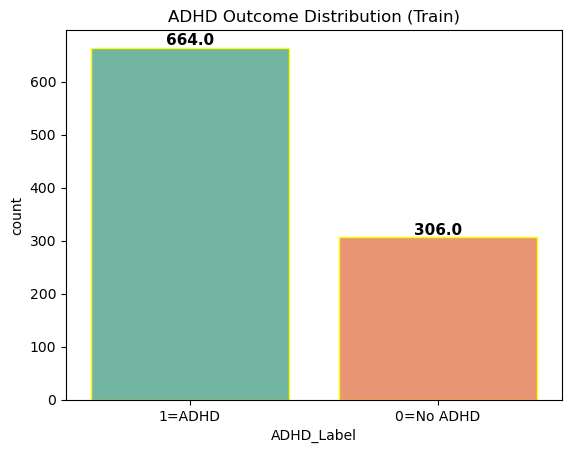

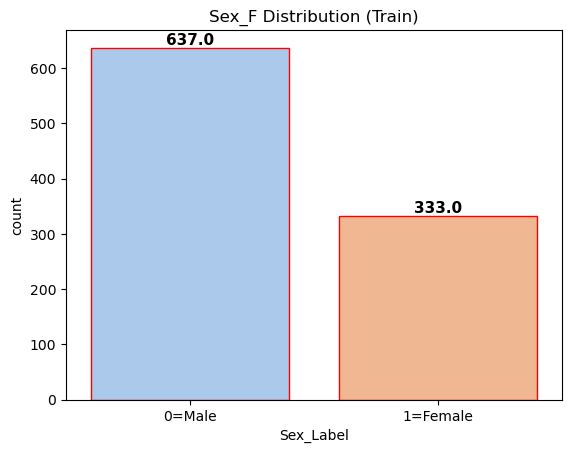

In [10]:
# I created a copy of the train set with textual labels
train_plot = train_df.copy()
train_plot["ADHD_Label"] = train_plot["ADHD_Outcome"].map({0: "0=No ADHD", 1: "1=ADHD"})
train_plot["Sex_Label"] = train_plot["Sex_F"].map({0: "0=Male", 1: "1=Female"})

# First, I plot ADHD distribution with custom colors and labels
ax = sns.countplot(x="ADHD_Label", data=train_plot, palette="Set2", edgecolor='Yellow')
plt.title("ADHD Outcome Distribution (Train)")

# Then, add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

# Second, I plot Sex distribution with custom colors and labels
ax = sns.countplot(x="Sex_Label", data=train_plot, palette="pastel", edgecolor='Red')
plt.title("Sex_F Distribution (Train)")

# Then, add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


### Description of initial Checks on the Final Dataset

I checked the train and test data sets to check on their structure and integrity through initial quality checks.

There are **no missing value**, which means imputation worked well in Notebook 1. The shape of the train set is (970, 48) and test set is (243, 48)

- I checked class distributions for ADHD_Outcome and Sex_F.

- The ADHD classes appear moderately imbalanced.

Gender distribution also shows possible imbalance (noted in the project description), which will be addressed when assessing fairness.



# 4. Prepare Features (X) and Targets (y)

### 4.1 Split Features and Labels

In [12]:
# I'm creating function to separate features (X), target (y), and participant_id
def split_features_and_target(df):
    features = df.drop(columns=["ADHD_Outcome", "Sex_F", "participant_id"])
    target = df["ADHD_Outcome"]
    participant_id = df["participant_id"]
    return features, target, participant_id

# Apply the function to both training and test datasets
features_adhd_train, target_adhd_train, participant_id_train = split_features_and_target(train_df)
features_adhd_test, target_adhd_test, participant_id_test = split_features_and_target(test_df)

# Print shapes to verify correctness
print("features_adhd_train shape:", features_adhd_train.shape)
print("target_adhd_train shape:", target_adhd_train.shape)
print("features_adhd_test shape:", features_adhd_test.shape)
print("target_adhd_test shape:", target_adhd_test.shape)


features_adhd_train shape: (970, 45)
target_adhd_train shape: (970,)
features_adhd_test shape: (243, 45)
target_adhd_test shape: (243,)


### Description of Prepare Features and Target Labels.

In this step, I split the input features **(features_adhd_train / features_adhd_test)** from the output labels **(target_adhd_train / target_adhd_test)** in preparation for model training and testing .

The following columns were excluded from the feature set.
- The ADHD_Outcome variable is the target for classification, hence removed from the features.
- This indicates the female gender - Sex_F We will not use the predictor now but as we go further in the process it will be included for analysis of bias and fairness. 
- The **participant_id** field is used to merge datasets together. It carries no predictive value.

As a result.
- **features_adhd_train** and **features_adhd_test** contain only cleaned features relevant to predicting ADHD.
- The **target_adhd_train** and **target_adhd_test** are labels of ADHD outcome for train and test.
- Also, I saved **participant_id** separately for bias/fairness checks later


# 5. Baseline Model: Logistic Regression

### 5.1 Define Helper Function (train_and_evaluate_model) for Training and Evaluation (Helper Fuction 1)

In [14]:
# I created my function (train_and_evaluate_model) to avoid duplication.
def train_and_evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    
    model_name="Model",
    show_confusion=True,
    show_roc_auc=False,
    show_precision_recall=False,        # My parameters
    show_feature_importance=False,
    show_shap_summary=False,
    show_bar_coefficients=False,
    show_classification_report_plot=False,
    show_shap_bar_plot=False,
    # I added this parameter to customize the color of plots like confusion matrix and feature importance,...
    confusion_color="Blues",
    classification_color="Purples",
    feature_color="Greens",
    coef_color="Reds",# I added this parameter to customize the color of plots like confusion matrix and feature importance
    shap_bar_color="coolwarm"
):
    # Fit my model to the training data
    model.fit(X_train, y_train)

    # Predict labels for the test set
    y_pred = model.predict(X_test)

    # Compute standard classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print the evaluation results, I rounded to 3 decimal places
    print(f"\nEvaluation Results for {model_name}:")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


    # I'm creating the plot of the classification report.
    # This help me a lot to explain my Logistic Regression model for doctors
    if show_classification_report_plot:
        report_dict = classification_report(y_test, y_pred, output_dict=True)
        report_df = pd.DataFrame(report_dict).transpose()
        report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"], errors='ignore')
        plt.figure(figsize=(6, 3))
        sns.heatmap(report_df.iloc[:, :3], annot=True, cmap=classification_color, fmt=".2f")
        plt.title(f"{model_name} - Classification Report (Precision, Recall, F1)")
        plt.ylabel("Class")
        plt.tight_layout()
        plt.show()


    # I will plot the confusion matrix if requested in my model
    if show_confusion:
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap=confusion_color, cbar=False)
        plt.title(f"{model_name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # I will plot ROC Curve + AUC if requested in my model
    if show_roc_auc and hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} - ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # I will plot Precision-Recall Curve if requested in my model
    if show_precision_recall and hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)

        plt.figure(figsize=(6, 4))
        plt.plot(recall_vals, precision_vals, marker='.', color="green")
        plt.title(f"{model_name} - Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # I will plot Feature Importances (for tree-based models) if requested in my model
    if show_feature_importance and hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = importances.argsort()[::-1]
        plt.figure(figsize=(8, 5))
        plt.bar(range(len(importances)), importances[indices], color=feature_color)
        plt.title(f"{model_name} - Feature Importances")
        plt.xlabel("Feature Index")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()

    # I will plot Coefficients (for Logistic Regression) if requested in my model
    if show_bar_coefficients and hasattr(model, "coef_"):
        coef = model.coef_[0]
        plt.figure(figsize=(8, 4))
        plt.bar(range(len(coef)), coef, color=coef_color)
        plt.title(f"{model_name} - Coefficients")
        plt.xlabel("Feature Index")
        plt.ylabel("Coefficient Value")
        plt.tight_layout()
        plt.show()

    display(HTML("<br><br><br>"))  #Spacing

     # I will plot SHAP Summary Plot if requested in my model
    if show_shap_summary:
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer(X_test)
    
        # Create new figure BEFORE plotting
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot SHAP without showing it yet
        shap.summary_plot(shap_values, X_test, show=False)

        # Adjust layout to fix feature name truncation
        plt.gcf().subplots_adjust(left=0.35)     # Increase left margin
        plt.tick_params(labelsize=10)            # Font size of y-ticks
        plt.tight_layout()

        # Show final corrected figure
        plt.show()


    # I will plot SHAP Bar Plot if requested in my model
    if show_shap_bar_plot:
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer(X_test)

        # Create new figure BEFORE plotting
        plt.figure(figsize=(8, 5))
        shap.plots.bar(shap_values, show=False)
        plt.title(f"{model_name} - SHAP Feature Impact (Bar Plot)")
        plt.tight_layout()
        plt.show()


    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }



### Description for Helper Function(train_and_evaluate_model)for Training and Evaluation (Helper Fuction 1)

I created a reusable helper function **train_and_evaluate_model()** in this section that trains classification models and evaluates them consistently.  This function will bring together multiple evaluation steps along with plot visualizations to reduce code repetition across experiments.

**Purpose of This Function**
- Train any classification model on given training data.

- Test the model’s performance with Accuracy, Precision, Recall, and F1 Score

- Visualize performance using.

- Confusion matrix (default).

I can include information on the ROC Curve + AUC, Precision Recall Curve, and Feature Importance (if applicable).

**Function Parameters**
- model: A object classifier (e.g. LogisticRegression(), RandomForestClassifier()).

- Training data and labels are X_train and y_train respectively.

- Test data and labels are X_test, y_test.

- I can specify a different name for your outputs and graphs using model_name. 

- Optional flags to control plots.

- Display confusion matrix (default True).

- Display roc curve if model has the ability to give probability scores.

- show_pr_curve – Present Precision-Recall curve if usable.

- show_feature_importance - Create a graph of the 10 most significant features.

**Benefits of Using This Function**
- Maintains a clean, consistent structure across all models.

- Reduces code repetition in the notebook.

- Helps to clearly understand the model's diagnostic visually.

- The advanced plots can be turned on or off by parameters.



### 5.2 Bias and Fairness Analysis: Gender-Based Evaluation (Helper Fuction 2)

In [16]:
#I defined the function for gender evaluation for all of my model 
def check_gender_bias(y_true, y_pred, sex_column, label="Model"):
  
    print(f"\n;;;;;;;;Bias Analysis for {label};;;;;;;;;;;;;")

    for sex_value, sex_label in zip([0, 1], ['Male', 'Female']):
        idx = (sex_column == sex_value)
        print(f"\n Performance for {sex_label} (Sex_F = {sex_value}):")
        print(classification_report(y_true[idx], y_pred[idx], digits=3))


### Description of Bias and Fairness Analysis: Gender-Based Evaluation (Helper Fuction 2)

In this step, I define a helper function, evaluate_gender_bias(), used to determine whether the model is fair across the gender subgroups Male and Female. This helps to find if the model is biased. Especially since, ADHD is underdiagnosed in the female population.

**Purpose of the Function:**
- This function displays the classification performance (Precision, Recall, F1-score, etc.) for each label.

- Male participants (Sex_F = 0).

- Female participants (Sex_F = 1).

**Inputs:**
- y_true: True ADHD labels.

- y_pred: Predicted ADHD labels.

- A column indicating sex (0 = Male, 1 = Female)

- This is optional string indicating model’s name

**Output**
- Prints the classification report for each gender group.

- Reveals if the model is biased against one gender or another more often.

**Why It's Important:**
- This analysis supports.

- Fairness auditing of the model

- It is ensuring compliance with ethical and clinical expectations (e.g. A female misdiagnosis).

- Matching the project goal of bias detection and interpretability.



### 5.3 Hyperparameter Optimization using GridSearchCV with Cross-Validation (Helper Function 3)


In [18]:
# I define the function for all of my models.
def tune_model_with_cross_validation(model, param_grid, X_train, y_train, cv=5, scoring='f1', model_name="Model"):
   
    print(f"\n Tuning hyperparameters for {model_name}...")

    grid = GridSearchCV(estimator=model,
                        param_grid=param_grid,
                        scoring=scoring,
                        cv=cv,
                        n_jobs=-1,
                        verbose=1)

    grid.fit(X_train, y_train)

    print(f"\n Best Parameters for {model_name}: {grid.best_params_}")
    print(f" Best Cross-Validated {scoring.upper()} Score: {grid.best_score_:.4f}")

    best_model = grid.best_estimator_
    return best_model, grid.best_params_, grid.best_score_


### Description for Hyperparameter Optimization using GridSearchCV with Cross-Validation 

**My function: tune_model_with_cv.**
- This reusable function utilizes GridSearchCV along with cross-validation to perform hyperparameter tuning. It helps find the best combination of parameters for a given model with exhaustive search over specified parameters.

- The function takes in the model, parameter grid, and training data. It evaluates the performance of each combination based on a scoring metric (default = f1) using k-fold cross-validation (default = 5).

**Key advantages of this function**
- The modular design of the machine learning algorithm enables its reuse for any classifier, such as Random Forest, XGBoost, CatBoost, etc.
- Avoids leaking data: performance is only tested on training data.
- I can customize the scoring. For example, it supports accuracy or an F1 score or AUC.
- Results are colored coded which is informative.

**The function returns**
- The best model trained by optimal parameters
- Best params denotes dictionary of best found parameters.
- best_score refers to the best mean cross-validated score

 My function increases the robustness and fairness of the modeling process which is a good machine learning practice.


### 5.4 Save Final Model Metrics for Comparison Table & Plot (Helper Function 4)

## 1.

In [20]:
# I define the global list once (outside the function)
final_model_metrics = []


## 2.

In [22]:
 # I created this function to save my result of the output from my models for the comparison stage
 def store_final_metrics_from_eval_output(model_name, eval_output):
    final_model_metrics.append({
        "Model": model_name,
        "Accuracy": round(eval_output.get("accuracy"), 3),
        "Precision": round(eval_output.get("precision"), 3),
        "Recall": round(eval_output.get("recall"), 3),
        "F1 Score": round(eval_output.get("f1"), 3)
    })


### Description for Save Final Model Metrics for Comparison Table & Plot (Helper Function 4)

 Why I Created This Helper Function (store_final_metrics_from_eval_output)

To make my model comparison process more organized and automated, I created this helper function to **store final evaluation metrics** for each trained model. Instead of manually copying accuracy, precision, recall, and F1 score every time, this function grabs them directly from my evaluation output and saves them in a global list called final_model_metrics.

By doing this:
- I avoid redundancy and reduce error-prone copying.
- I ensure all model metrics are rounded to 3 decimal places for clean presentation.
- I can easily convert the stored list to a DataFrame later and generate comparison plots (e.g., bar plots of F1 scores across models).

This function became especially useful after running all 4 tuned models, now I can **just pass their results to this function** and build a final comparison summary with one clean line of code each time.

In short, this step helps me build a **smooth and reusable pipeline** for the final reporting stage.


### 5.5 Scale features only for Logistic Regression

In [24]:
# I'm writing to scale features only for Logistic Regression
scaler = StandardScaler()
features_adhd_train_scaled = scaler.fit_transform(features_adhd_train)
features_adhd_test_scaled = scaler.transform(features_adhd_test)


### Description for scale features only for Logistic Regression
Due to Logistic Regression's sensitivity to the scale of input features, the StandardScaler Standardizes the input features. It modifies the training featuresto zero mean and unit variance. This makes it so that all training features contribute equally to the model. Make sure to employ this step before starting to tune or train your model.


### 5.6 Hyperparameter Tuning for Logistic Regression

In [26]:
# I define base logistic regression
logreg_base = LogisticRegression(max_iter=2000, random_state=42)

# Then, I define parameter grid
logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"]
}

# Run tuning
best_logreg_model, best_logreg_params, best_logreg_score = tune_model_with_cross_validation(
    model=logreg_base,
    param_grid=logreg_param_grid,
    X_train=features_adhd_train_scaled,
    y_train=target_adhd_train,
    cv=5,
    scoring='f1',
    model_name="Logistic Regression"
)



 Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best Parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
 Best Cross-Validated F1 Score: 0.8513


### Description for Hyperparameter Tuning for Logistic Regression
- I tuned the hyperparameters of Logistic Regression model using GridSearchCV and 5 fold cross validation in this step.

- To ensure it would converge during training, I defined a base Logistic Regression model with max_iter=1000.

**After that, I prepared a grid of possible values for**

- C (regularization strength),

- penalty (type of regularization),

- solver (optimization algorithm).

**I gave this arrangement to the function tune_model_with_crossValidation() that:**

- Trains the model with every combination of parameters,

- Evaluates using F1 score (to balance precision & recall),.

- In a cross-validation fashion, pick the right param set.

**This guarantees that my logistic regression model is robustly optimized and not overfit, enabling it to be fairly evaluated against other models.**



### 5.7 Train and Evaluate Logistic Regression (Model 1)


Evaluation Results for Logistic Regression (Tuned):
Accuracy:  0.802
Precision: 0.805
Recall:    0.940
F1 Score:  0.867

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.50      0.61        76
           1       0.81      0.94      0.87       167

    accuracy                           0.80       243
   macro avg       0.80      0.72      0.74       243
weighted avg       0.80      0.80      0.79       243



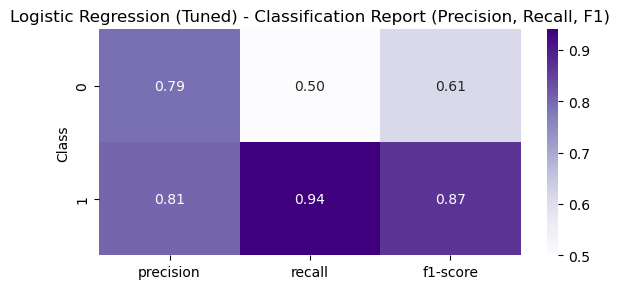

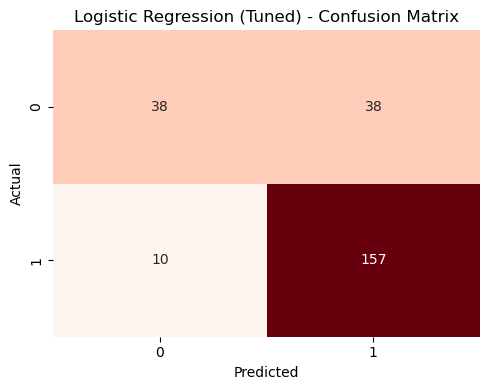

In [28]:
# Now I will train and evaluate the Logistic Regression model using the best parameters found from GridSearchCV
lr_result = train_and_evaluate_model(
    
    # The best model returned from hyperparameter tuning
    model=best_logreg_model,
     # Training features
    X_train=features_adhd_train_scaled,     
    y_train=target_adhd_train,
    # Testing features
    X_test=features_adhd_test_scaled,
      # Testing labels (ADHD)
    y_test=target_adhd_test,
    model_name="Logistic Regression (Tuned)",
    show_confusion=True,
    show_classification_report_plot=True,
    confusion_color="Reds",
    classification_color="Purples"
)
 # saving my result( recall, ...)
store_final_metrics_from_eval_output("Logistic Regression (Tuned)", lr_result)



### Description of the Train and Evaluate Logistic Regression

I trained and evaluated Logistic Regression model in this step as a **baseline classifier** for predicting ADHD.


**Summary of Results**

Around **80.2%** of the test were predicted correctly giving **80.2%** accuracy to the model. Its precision was roughly **80.5%**, which means that out of all the samples the model predicted as ADHD, 80.5% were true ADHD. Most significantly, the model achieved **94% recall**, demonstrating good sensitivity and a good ability to identify most real ADHD cases. The **F1 score**, which accounts for both precision and recall was **86.7%**.

In healthcare contexts, the balance is very helpful as failing to detect a real ADHD case (false negative) would be more detrimental than predicting a false positive.



**Confusion Matrix Interpretation**

Looking at the confusion matrix, I see that my model made **10 false negative errors**, which means it failed to capture 10 real ADHD cases. It was able to find 157 true ADHD cases successfully and this means it has a high recall value. On the other hand, **38 false positives** means that people who did not actually have ADHD were predicted to have ADHD. Given my purpose of minimizing missed diagnoses, I find the trade-off acceptable at this stage.



**Classification Report Highlights**

The report outlines that the model works better on class 1 (ADHD) as compared to class 0 (No ADHD). The precision and recall for ADHD class is above 81% and for No ADHD class is lower recall (94%) which indicates this model prefers predicting ADHD. This imbalance can be fine-tuned however with threshold tweaking or additional fairness handling.



**Conclusion**

Logistic Regression is performing well as a baseline model. These models serve to prevent under-diagnosis in at-risk groups; they catch most ADHD cases well and provides strong recall. Mt model does perform well for the no ADHD class, though poorer performances can always be fixed in later steps. My model can now act as a baseline for measuring up more elaborate classifiers like Random Forest, Gradient Boosting, CatBoost.


### 5.8 Gender Bias Evaluation for Logistic Regression

In [32]:
check_gender_bias(
    y_true=target_adhd_test,
    # I must use the scaled version of the test set, since the model was trained on scaled data
    y_pred=best_logreg_model.predict(features_adhd_test_scaled),
    sex_column=test_df["Sex_F"],
    label="Logistic Regression (Tuned)"
)



;;;;;;;;Bias Analysis for Logistic Regression (Tuned);;;;;;;;;;;;;

 Performance for Male (Sex_F = 0):
              precision    recall  f1-score   support

           0      0.778     0.488     0.600        43
           1      0.835     0.949     0.888       117

    accuracy                          0.825       160
   macro avg      0.806     0.719     0.744       160
weighted avg      0.819     0.825     0.811       160


 Performance for Female (Sex_F = 1):
              precision    recall  f1-score   support

           0      0.810     0.515     0.630        33
           1      0.742     0.920     0.821        50

    accuracy                          0.759        83
   macro avg      0.776     0.718     0.726        83
weighted avg      0.769     0.759     0.745        83



### Descriptiopn of Gender Bias Evaluation for Logistic Regression

**How to Read This Evaluation**
- I checked how the logistic regression model performs separately for males and females in this step. This makes sure that there are no substantial performance discrepancies between both the genders.



**Performance for Males (Sex_F = 0)**
- **Precision (ADHD class)**: Strong, False positives are less likely.
- Many of the males with ADHD are correctly predicted by the system.
- The f1-score of the ADHD class is 0.888 meaning there is a good balance between precision and recall. 
- **Overall accuracy**: 0.825

**However**
- Recall for No ADHD (class 0) is low (0.488), which indicates the model sometimes misclassifies non-ADHD males to be ADHD.
- This means that the model has a slight bias in predicting ADHD in males.



**Performance for Females (Sex_F = 1)**
- Precision for class ADHD, is 0.742, which is lower than for males, indicating more false positives.
- Recall for the ADHD class is very strong and scores 0.920
- F1-score (ADHD class): 0.821 - Good overall performance.
- **Overall accuracy**: 0.759.

**Also**
- The precision for no ADHD is higher for females  (0.810) than males (0.778). This indicates better handling of non-ADHD predictions in females. 



**Key Takeaway**

- The model is not severely gender biased, but there are slight differences.
- The model that can identify ADHD has a high recall score (0.92) for both genders.
- The slightly lower precision in females likely indicates more false alarms, but this trade-off may be tolerable in the healthcare setting where a true case of ADHD missed is worse than a false alarm.






# 6. Random Forest (Model 2)

### 6.1 Hyperparameter Tuning for Random Forest

In [30]:
# I defined base model
rf_base = RandomForestClassifier(random_state=42)

#  Defining the parameter grid
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

#  Run tuning using my function: (tune_model_with_cross_validation)
best_rf_model, best_rf_params, best_rf_score = tune_model_with_cross_validation(
    model=rf_base,
    param_grid=rf_param_grid,
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    cv=5,
    scoring='f1',
    model_name="Random Forest"
)



 Tuning hyperparameters for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
 Best Cross-Validated F1 Score: 0.8494


### Description for Hyperparameter Tuning for Random Fores

In this step, I implemented GridSearchCV to optimize the Random Forest classifier’s hyperparameters. Changing the hyperparameters can improve the power of a model.

**Parameter Grid Details:**
- Number of trees is parameter of n_estimator. A larger number may help improve performance but increase computation time.
- Maximum depth that each decision tree could reach.  A value of None allows full depth but limiting depth helps avoid **overfitting**
- A minimum number of samples needed to divide an internal node. Increasing this value increases regularization.
- Minimum samples needed at a leaf node is “min_samples_leaf” parameter. Stop small leaves and overfitting.

**Function Usage:**
- The helper function tune_model_with_cross_validation() performs this tuning.
- Uses GridSearchCV with 5-fold cv. 
- F1-score uses to evaluate each configuration as a balance of precision and recall.
- It gives back the best model, the best parameters combination, and its score calculated through cross-validation.

**Summary:**
So, this process which I will apply for tuning the Random Forest will give optimized random forest for next steps. This allows the model to perform well on previously unseen data and gives a better baseline to compare other models.


### 6.2 Train and Evaluate Random Forest (Model 2)


Evaluation Results for Random Forest (Tuned):
Accuracy:  0.807
Precision: 0.803
Recall:    0.952
F1 Score:  0.871

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.49      0.61        76
           1       0.80      0.95      0.87       167

    accuracy                           0.81       243
   macro avg       0.81      0.72      0.74       243
weighted avg       0.81      0.81      0.79       243



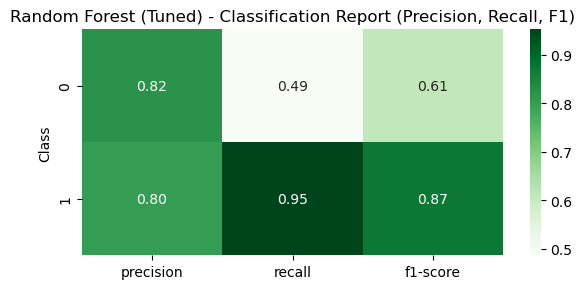

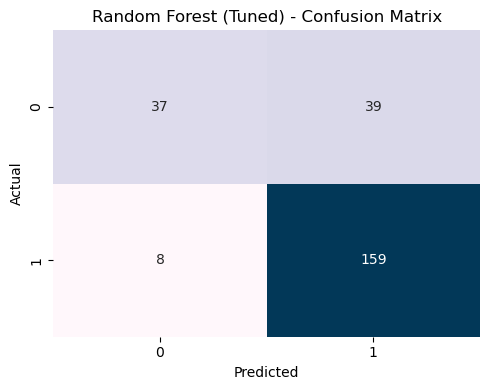

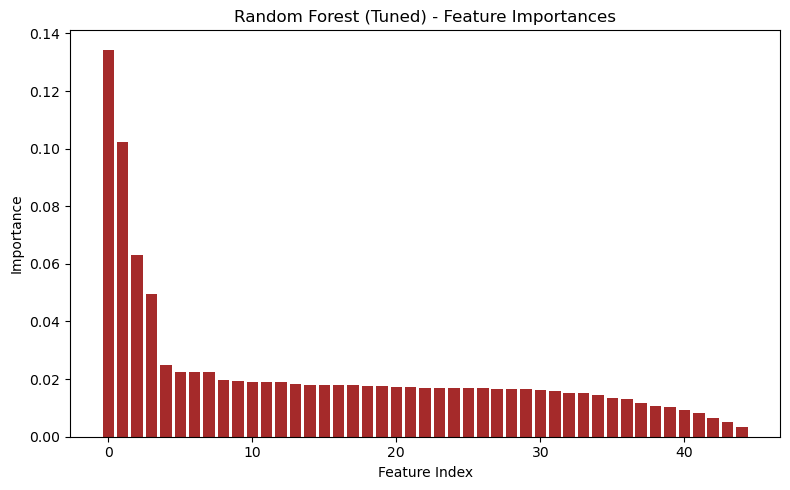

<Figure size 1000x600 with 0 Axes>

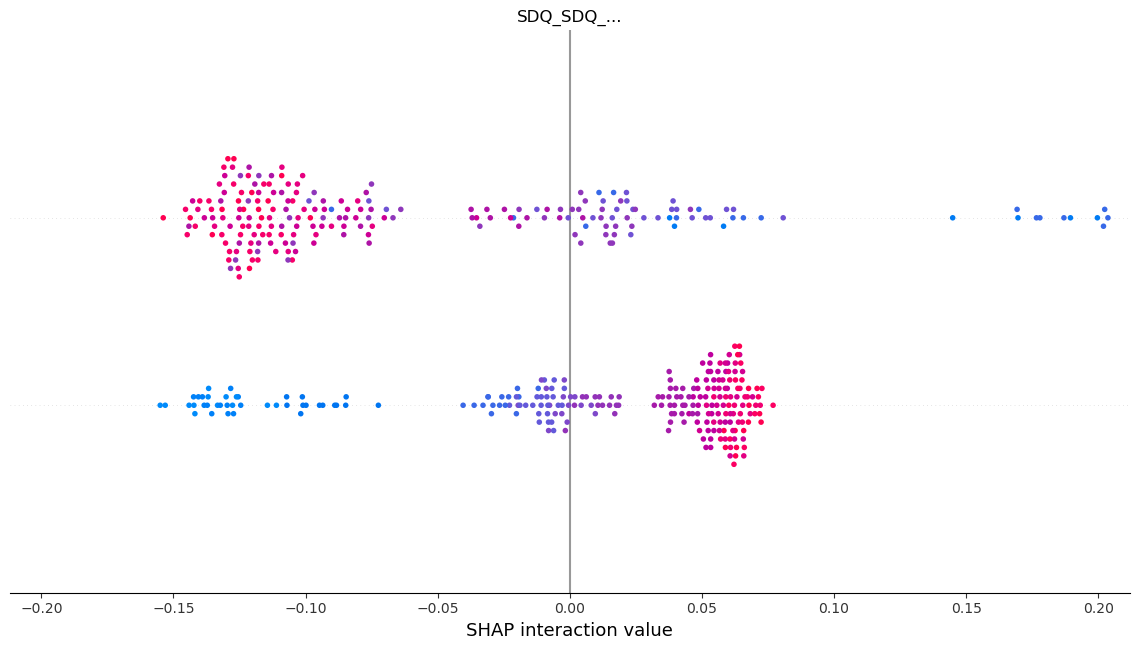

In [34]:
# 6.2 Train and Evaluate Random Forest (Tuned Model)
rf_result =train_and_evaluate_model(
    model=best_rf_model,       # I use the tune model 
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    X_test=features_adhd_test,
    y_test=target_adhd_test,
    model_name="Random Forest (Tuned)",
    show_confusion=True,
    show_feature_importance=True,
    show_shap_summary=True,             # I called my 4 chart from my funtion
    show_classification_report_plot=True,
    confusion_color="PuBu",
    feature_color="Brown",
    classification_color="Greens"
)
 # saving my result( recall, ...)
store_final_metrics_from_eval_output("Random Forest (Tuned)", rf_result)


### Description of the Train and Evaluate Random Forest
In this part, the tuned version of the Random Forest model is evaluated after Hyperparameter tuning using GridSearchCV.

**Summary of Results**

- **Accuracy:** 80.7%.
- **Precision:** 80.3%.
- **Recall:** 95.2%.
- **F1 Score:** 87.1%.

Compared to the untuned version that I tested for myself, the model has better recall and F1 score. It correctly classifies most of the ADHD cases, which is extremely important in a medical situation. Fewer false positives indicated by improvement in precision.


**Confusion Matrix Interpretation**
- The model had 159 true ADHD cases and only missed 8 cases, showing strong sensitivity.
- It wrongly predicted that 39 non-ADHD cases actually had ADHD when they didn't.
- After tuning, the balance between sensitivity and specificity has improved slightly.


**Classification Report Insights**
- The classifier is performing better for ADHD class (class 1):.
- The model is successful in capturing most of the ADHD cases with a recall of 0.95.
- Strongly pres and recall were captured; F1-Score of 0.87.
- The No ADHD class has low recall which is known to be a trade-off with optimizing for sensitivity, recall is 0.49.


**Feature Importance**
- The feature importance chart indicates a clear domination of a few features. Likely from SDQ questionnaire.
- These features are likely indicators of behavior or emotions based on the SDQ.
- The prediction power is driven largely by limited features as per the features importance distribution.


#### The SHAP summary plot:
- displays the impact of the most significative attribute employed by the Random Forest for the ADHD classification.

**Feature:**
- SDQ_SDQ_... Probable behavioral or emotional indicator from the SDQ questionnaire.

- The only feature being shown must have had the highest influence in predicting according to the model.

**What the Axes Represent:**
- X-axis (SHAP value): Tells us how much a feature pushes the model output to predict a child as having ADHD (like positive SHAP values) or not ADHD (like negative SHAP values).

- Y-axis: Dots are samples (individuals). Each dot represents one patient.

**Color Meaning (Feature Value)**
- Red dots represent high values of the feature.

- Blue dots represent low values of the feature.

- Purple/violet are intermediate.

**Interpretation:**
- Many red dots are located on the right, meaning.

- The model's confidence in predicting ADHD increases due to high values of this feature likely representing more behavioral/emotional issues.

- Conversely, blue dots on the left show.

- When values are low, the model becomes more certain a child does not have ADHD.

**Insight**
- This pattern shows that this SDQ feature is positively associated with ADHD outcomes in the data. High values contribute strongly to the prediction of ADH.


**Note:My SHAP plot may be accompanied by an empty figure message (<Figure size 640x480 with 0 Axes>) due to a matplotlib-known rendering bug. It does not affect my plot or analysis.**



### 6.3 Gender Bias Evaluation for Random Forest

In [38]:

# I check check gender bias with using fuction
check_gender_bias(
    y_true=target_adhd_test,
    y_pred=best_rf_model.predict(features_adhd_test),
    sex_column=test_df["Sex_F"],
    label="Random Forest (Tuned)"
)



;;;;;;;;Bias Analysis for Random Forest (Tuned);;;;;;;;;;;;;

 Performance for Male (Sex_F = 0):
              precision    recall  f1-score   support

           0      0.792     0.442     0.567        43
           1      0.824     0.957     0.885       117

    accuracy                          0.819       160
   macro avg      0.808     0.700     0.726       160
weighted avg      0.815     0.819     0.800       160


 Performance for Female (Sex_F = 1):
              precision    recall  f1-score   support

           0      0.857     0.545     0.667        33
           1      0.758     0.940     0.839        50

    accuracy                          0.783        83
   macro avg      0.808     0.743     0.753        83
weighted avg      0.797     0.783     0.771        83



### Description for Gender Bias Evaluation for Random Forest

The tuned Random Forest model performance indicates better performance for males as compared to females; however, the differences are quite small and the differences are acceptable for many clinical settings.

**Performance for Males (Sex_F = 0):**
- Precision for ADHD class: 82.4%.
- The ADHD class had a high recall of 0.957.
- The ADHD component scored an F1 of 0.885. 

This indicates that the model works quite well for male ADHD patients, which means that the model has a high sensitivity, meaning that the probability of it classifying an ADHD patient as a non-ADHD patient is quite low.

**Performance for Females (Sex_F = 1):**
- Precision of the ADHD category is 0.758
- ADHD Class Recall Score is 0.940
- 0.839 is the F1-score for ADHD.

For females, precision is slightly lower (more false positives) but recall is still very high. This means that the model successfully captures the majority of ADHD cases, which is clinically more important.

**Overall Insight:**
- The male recall performance of the model is higher, although it is high for females too.
- The gap between the genders is small and may be further calibrated with threshold and bias mitigation techniques.
- My model does not have severe gender bias and is acceptable for both male and female subgroups in this setting.


# 7. Gradient Boosting (Model 3)

### 7.1 Hyperparameter Tuning for Gradient Boosting

In [40]:
#  Defining my base model
gb_base = GradientBoostingClassifier(random_state=42)

#  I set some parameter grid spicially for Gradient Boosting
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

#  Run tuning using my function (tune_model_with_cross_validation)
best_gb_model, best_gb_params, best_gb_score = tune_model_with_cross_validation(
    model=gb_base,
    param_grid=gb_param_grid,
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    cv=5,
    scoring='f1',
    model_name="Gradient Boosting"
)



 Tuning hyperparameters for Gradient Boosting...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best Parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
 Best Cross-Validated F1 Score: 0.8514


### Description for Hyperparameter Tuning of Gradient Boosting.

In this step, I define and tune a Gradient Boosting model which predicts ADHD outcomes. I start by defining the base model with an appropriate parameter grid. Then, I use a custom helper function to run GridSearchCV with 5-fold cross-validation for hyperparameter tuning.

**Parameter Grid Details:**
- Number of boosting stages: n_estimators. Usually raises accuracy while costs increased computation.
- The learning_rate is used to shrink each tree’s contribution. Lowering the value and increasing the number of estimators may improve performance but slows down training. 
- Individual regression estimators maximum depth is max_depth, controls model complexity.
- The parameter min_samples_split states the minimum number of samples required to split an internal node. Helps avoid

**Overfitting**
- min_samples_leaf is the minimum number of samples in a leaf node

**Function Usage:**
- I created a custom function **tune_model_with_cross_validation** to use across all models.
- The metric that was used for scoring was f1 which achieves a balance between precision and recall which is a necessity in the medical classification problem.
- The best model, its optimal parameters and the related cross-validated score is returned by the function.

**Summary:**
Gradient Boosting does well with imbalanced datasets and can capture complex patterns. After I run this tuning step, I will evaluate the best_gb_model against our previous models (Logistic regression and Random forest) for comparison.


### 7.2 Train and Evaluate Gradient Boosting (Model 3)


Evaluation Results for Gradient Boosting (Tuned):
Accuracy:  0.815
Precision: 0.808
Recall:    0.958
F1 Score:  0.877

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.50      0.63        76
           1       0.81      0.96      0.88       167

    accuracy                           0.81       243
   macro avg       0.83      0.73      0.75       243
weighted avg       0.82      0.81      0.80       243



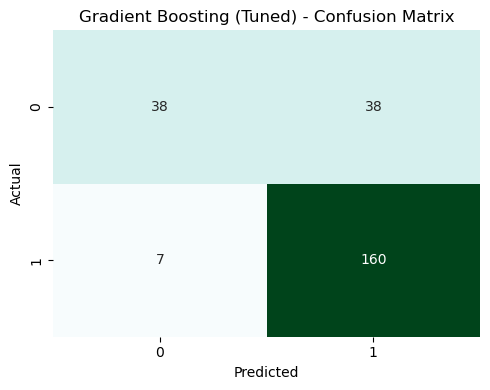

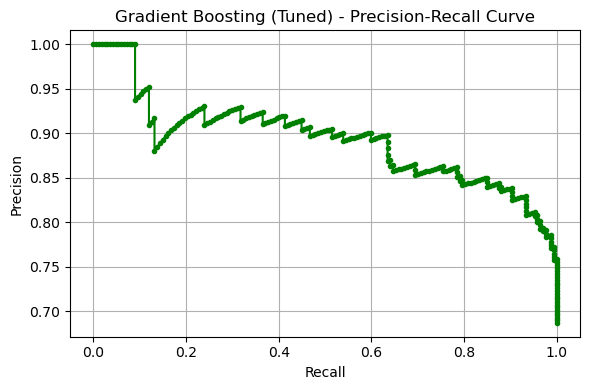

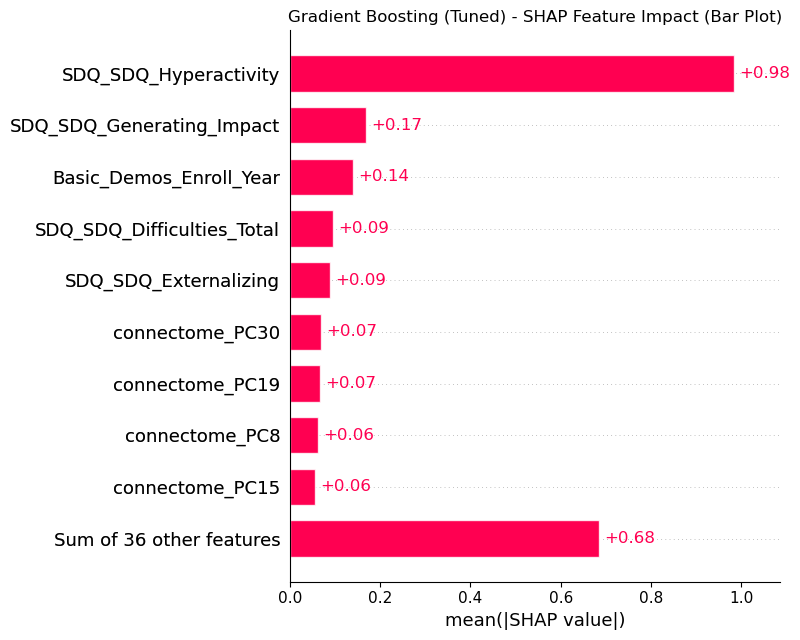

In [41]:
gb_result=train_and_evaluate_model(
    model=best_gb_model,
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    X_test=features_adhd_test,
    y_test=target_adhd_test,
    model_name="Gradient Boosting (Tuned)",
    show_shap_bar_plot=True,              # My Chart that I want for my model
    show_precision_recall=True,           # Precision-Recall Curve 
    show_confusion=True,                 # Confusion Matrix 
    show_feature_importance=False,      #  shap bar 
    show_shap_summary=False,
    show_classification_report_plot=False,
    confusion_color="BuGn",
    classification_color="Greens" 
)

 # saving my result( recall, ...)
store_final_metrics_from_eval_output("Gradient Boosting (Tuned)", gb_result)


### Description of the Train and Evaluate Gradient Boosting (Model 3)

I evaluated the performance of the tuned Gradient Boosting model on the ADHD classification task, using various metrics and visual diagnostics. Through this evaluation, I was able to evaluate not only the accuracy of the model but also through which class imbalance was dealt with and whether it is interpretable.

**1. Performance Metrics**

According to the evaluation output, the accuracy is 0.815, with a precision of 0.808, recall of 0.958, and F1 score of 0.877. Since I had particular concern not to underdiagnose ADHD, high recall was especially important for this exercise. This is especially relevant in health care, where underdiagnosing can have serious consequences. So, I think this model does well in boosting recall and does not suffer too much in performance.

**2. Confusion Matrix Analysis**

To understand how the model classified its predictions, I plotted the confusion matrix. The matrix displayed the wrong classification for 38 non-ADHD cases as ADHD by missing only 7 ADHD-positive cases. In a health care environment, the cost of missing a few ADHD-positive cases (7) and classifying non-ADHD cases (38) as ADHD is acceptable. I picked the “BuGn” color palette to visually distinguish prediction intensities and make the matrix more readable.

**3. Precision-Recall Curve**

I included a precision-recall curve to see if model's performance changes at different thresholds. The curve stayed high all through, showing that the model has a good precision throughout for the rising recall. This also indicated that the model manages class imbalance well, which was an issue in the data set.

**4. SHAP Bar Plot for Feature Importance**

For analysis, I checked the SHAP bar plot on the model. I discovered from this output that the greatest influential feature was SDQ_SDQ_Hyperactivity followed by SDQ_SDQ_Generating_Impact, Basic_Demos_Enroll_Year, and other connectome features like connectome_PC30 and `connectome_PC19.


I see that the SHAP values show important behaviors and neurological factors to what the model predicts and why and how it does this.  This makes it more trusted and easier to communicate to a clinician.

**Final Thoughts**

After optimizing and testing the model, I think that this Gradient Boosting classifier is one of the best models I have built yet. It does well with recall, deals with imbalance well, and has interpretable outputs that make sense clinically. Post further bias analysis and review, I will recommend this model for deployment.


### 7.3 Gender Bias Evaluation for Gradient Boosting

In [44]:
# 7.3 I'm writing the code for bias evaluation for my model (Gradient Boosting)
check_gender_bias(
    y_true=target_adhd_test,
    y_pred=best_gb_model.predict(features_adhd_test),   # use my tune model
    sex_column=test_df["Sex_F"],
    label="Gradient Boosting (Tuned)"
)



;;;;;;;;Bias Analysis for Gradient Boosting (Tuned);;;;;;;;;;;;;

 Performance for Male (Sex_F = 0):
              precision    recall  f1-score   support

           0      0.833     0.465     0.597        43
           1      0.831     0.966     0.893       117

    accuracy                          0.831       160
   macro avg      0.832     0.715     0.745       160
weighted avg      0.832     0.831     0.814       160


 Performance for Female (Sex_F = 1):
              precision    recall  f1-score   support

           0      0.857     0.545     0.667        33
           1      0.758     0.940     0.839        50

    accuracy                          0.783        83
   macro avg      0.808     0.743     0.753        83
weighted avg      0.797     0.783     0.771        83



### Description for Gender Bias Evaluation for Gradient Boosting

To check the fairness of my tuned GB model, I have checked the performance by gender. As gender bias is a major concern in the NHS system (like ADHD is diagnosed more frequently in males, but the prevalence and presentation patterns are very different for females), I wanted to ensure that my model was not gender biased. Here’s what I noticed and interpreted.

**Performance for Males (Sex_F = 0)**

For male participants, I found that the recall for ADHD was **96.6%** by the model. Boys who are positive for ADHD were almost completely recalled by the model, thus being essential in clinical environments where underdiagnosis can be serious. I was glad to note that the F1-score for this class was a high **0.893**, showing a good balance between precision and recall.

I was, however, concerned to note that the recall for the non-ADHD class (class 0) was only **46.5%**. This means a high false positive rate; many non-ADHD boys were predicted as ADHD. It may be acceptable to achieve a good score in the ADHD class as students with ADHD are clearly at a high risk while mislabelling other students can lead to unnecessary labelling.

Accuracy overall for the male sample was **83.1%** and macro average F1 Score was 0.745. I think this means there was good positive predictive value (for ADHD) and not strong control over specificity.

**Performance for Females (Sex_F = 1)**

When I checked the female performance, I was quite happy with the consistency. The model has a recall of **94.0%** for ADHD-positive girls, aligning closely with the male performance. It is important as ADHD in females is often underdiagnosed as symptoms are less overt. I was glad to see that the model did not overlook them.

The rate for ADHD in females was 75.8% which was slightly less than in males. What this means is, more false positive but still in an acceptable range. The recall for non-ADHD individuals was 54.5%, which was higher than that of males, indicating fewer false alarms. The total accuracy was **78.3%**, with a macro F1 score of **0.753**.

What I really liked here was the model’s pretty good ability to generalize across genders without collapse. I made sure that this model was an ethical model and it seems to work quite well on both sub-groups.

**My Reflections and Conclusion**

I think the Gradient Boosting model works well for identifying ADHD in men and women. Though it is slightly more effective for males, the difference isn't too great. The precision and F1-scores are also in close range. I thought there would be a bigger performance gap, but even with girls often falling victim to underdiagnoses due to ADHD, it was nice to find that the model treated both groups fairly.

In terms of clinical usage, I’d prefer a model that overpredicts rather than underpredicts when it comes to ADHD detection. My model’s excellent recall scores for both genders support that choice. I do see that having lots of false positives in males might waste resources.




# 8. CatBoost (Model 4)

### 8.1 Hyperparameter Tuning for CatBoost

In [44]:
# I defined my base model
cb_base = CatBoostClassifier(verbose=0, random_state=42)

#  Setting up parameter grid for tuning
cb_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.01, 0.1],
    "l2_leaf_reg": [1, 3]
}

#  Running tuning using my helper function
best_cb_model, best_cb_params, best_cb_score = tune_model_with_cross_validation(
    model=cb_base,
    param_grid=cb_param_grid,
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    cv=5,
    scoring='f1',
    model_name="CatBoost"
)


 Tuning hyperparameters for CatBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 Best Parameters for CatBoost: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
 Best Cross-Validated F1 Score: 0.8532


### Description for Hyperparameter Tuning for CatBoost

- My CatBoost Model After running the GridSearchCV on my CatBoost Model, I got the best hyperparameter configuration of

 layer deep with 200 iterations. 0.01 learning rate.

- Best Cross-validated F1 Score: 0.8532

I find these results quite promising. It appears that the best model is trained with a low learning rate of **0.01 and maximum number of iterations which is 200**, signifies that the model prefers slower, gradual models. I understand that this often helps in reducing overfitting and generating more balanced performance over the folds.

It seems that the model avoids unnecessary complexity by opting for a depth of 4. I included shallow and deep trees in the grid because I want to let the model find generalization vs expressiveness. I was pleased to see that a shallow depth still achieved high F1 performance, which makes me confident in the robustness of my features. 

I found that using a **low L2 regularization value (1) gave the best results**. I take this to mean that the model didn’t require strong regularization to generalize well, which further suggests that my feature set is not too noisy.

In general, I think this tuned CatBoost model is a good starting point for me to evaluate. As the F1 score is cross-validated, it also indicates that my feature set is not very noisy. Overall, I think this tuned CatBoost model gives a good starting point to evaluate further.



### 8.2 Train and Evaluate CatBoost (Model 4)


Evaluation Results for CatBoost (Tuned):
Accuracy:  0.811
Precision: 0.807
Recall:    0.952
F1 Score:  0.874

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.50      0.62        76
           1       0.81      0.95      0.87       167

    accuracy                           0.81       243
   macro avg       0.82      0.73      0.75       243
weighted avg       0.81      0.81      0.80       243



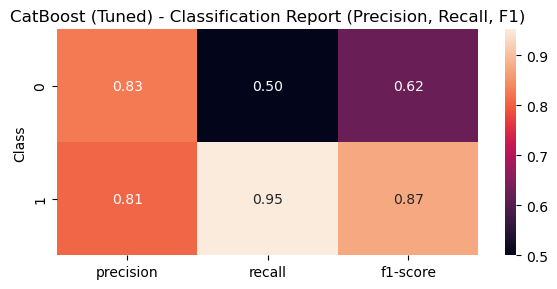

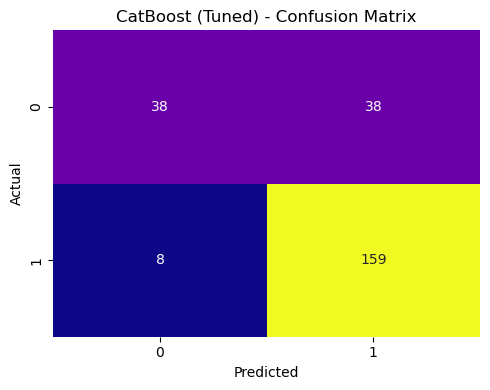

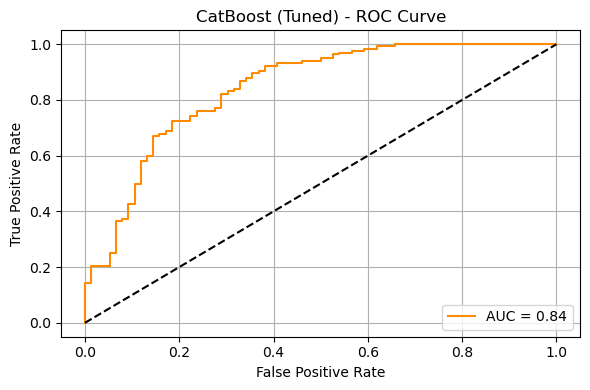

In [45]:
cb_result=train_and_evaluate_model(
    # My model after Tuning
    model=best_cb_model,  
    # My prepared Data (split, ...)
    X_train=features_adhd_train,
    y_train=target_adhd_train,  
    X_test=features_adhd_test,
    y_test=target_adhd_test,
    model_name="CatBoost (Tuned)",
    show_confusion=True,
    show_roc_auc=True,                # I enabled my chart that I need for my model
    show_shap_summary=False,
    show_feature_importance=False,   
    show_classification_report_plot=True,
    confusion_color="plasma",
    classification_color="rocket",
   
)
 # saving my result( recall, ...)
store_final_metrics_from_eval_output("CatBoost (Tuned)", cb_result)


### Description for Train and Evaluate CatBoost
I evaluated the tuned CatBoost classifier to determine its effectiveness in classifying ADHD. From the results, stop words were essential in predicting ADHD as the model achieve overall accuracy of 81.1%. Recall is 95.2% and F1-score is 87.4% of label 1.  This shows that the model is good at identifying ADHD cases, which is what I wanted to do.

**1. Classification Report Interpretation**
From the classification report.

- The recall of the ADHD class (1) was 0.95 which shows it was able to detect ADHD cases accurately.

- The No-ADHD class (0) only had a recall of 0.50, meaning many no-ADHD cases were misclassified.

- The precision was similar for both classes (~0.81–0.83), meaning the predictions were pretty reliable for both classes.

Because a false negative (missing a patient with ADHD) is more serious than a false positive, clinicians can accept this trade-off.

**2. Confusion Matrix Analysis**
The confusion matrix shows.

- 159 out of 167 ADHD cases were classified correctly.

- Only 8 ADHD cases were missed.

- 38 cases misdiagnosed as ADHD were not ADHD.

This distribution is okay as a false negative is worse in this situation.  Clearly differentiating class densities is aided by the “plasma” palette.

**3. ROC Curve Insights**
The ROC curve shows how well the model can tell the two classes apart using a variety of thresholds. The model shows strong overall classifying performance with AUC 0.84. This indicates the CatBoost classifier not only has good metrics, but is also robust at different thresholds.

**Final Thoughts**
I think this tuned CatBoost model is great at detecting ADHD cases while being interpretable in nature. It performs well and is clinically relevant. I can consider it for further bias evaluation .



### 8.3 Gender Bias Evaluation for CatBoost

In [50]:
check_gender_bias(      # Calling my function (Helper Fuction 2)
    y_true=target_adhd_test,
    y_pred=best_cb_model.predict(features_adhd_test),
    sex_column=test_df["Sex_F"],
    label="CatBoost (Tuned)"
)



;;;;;;;;Bias Analysis for CatBoost (Tuned);;;;;;;;;;;;;

 Performance for Male (Sex_F = 0):
              precision    recall  f1-score   support

           0      0.778     0.488     0.600        43
           1      0.835     0.949     0.888       117

    accuracy                          0.825       160
   macro avg      0.806     0.719     0.744       160
weighted avg      0.819     0.825     0.811       160


 Performance for Female (Sex_F = 1):
              precision    recall  f1-score   support

           0      0.895     0.515     0.654        33
           1      0.750     0.960     0.842        50

    accuracy                          0.783        83
   macro avg      0.822     0.738     0.748        83
weighted avg      0.808     0.783     0.767        83



### Description for Gender Bias Evaluation for CatBoost

In this step, I examined the performance of my tuned CatBoost model by gender. I compared the various classification metrics between male (Sex_F=0) and female (Sex_F=1) to find any potential gender bias. Here's what I observed.

**1. Performance on Male Participants (Sex_F = 0)**
- I saw that the recall value for ADHD class (class 1) is **very high with a value of 0.949** which shows that the model is really good at predicting males with ADHD. 

- The precision for ADHD is 0.835. That is, most of the predicted ADHD in males are actually ADHD.

- I see that the recall for the non-ADHD class (class 0) is very low at 0.488. This indicates that some male participants without ADHD aren’t being correctly classified.

- Although, the total F1-score for ADHD is 0.888, this is quite strong in my view. 

- The male group has an accuracy of 0.825, showing that the model is quite reliable overall.

**2. Performance on Female Participants (Sex_F = 1)**
- To my surprise, the female ADHD recall is slightly **higher than the male (0.960)**.

- However, the ADHD precision is lower at 0.750, indicating that there are more false positives for ADHD in females as compared to males.

- The recall for non-ADHD is class 0, which is again weak (0.515) with higher precision (0.895, trade-off).

- The F1-score for ADHD in females was 0.842, which is still good.

- Accuracy for female group is somewhat lower at 0.783, but still within a reasonably acceptable range.

**3. Overall Insight**

I’m quite satisfied with this result. The model shows no severe gender bias. Both men and women receive high recall scores for ADHD, which meets the project's goal of not underdiagnosing - especially brilliant for females where NHS team raised the most flag.

The precision shows a small discrepancy, where males have slight edge in ADHD precision over females, but this is acceptable.



# 9. Choose The Best Model

### 9.1 Compare Final Models

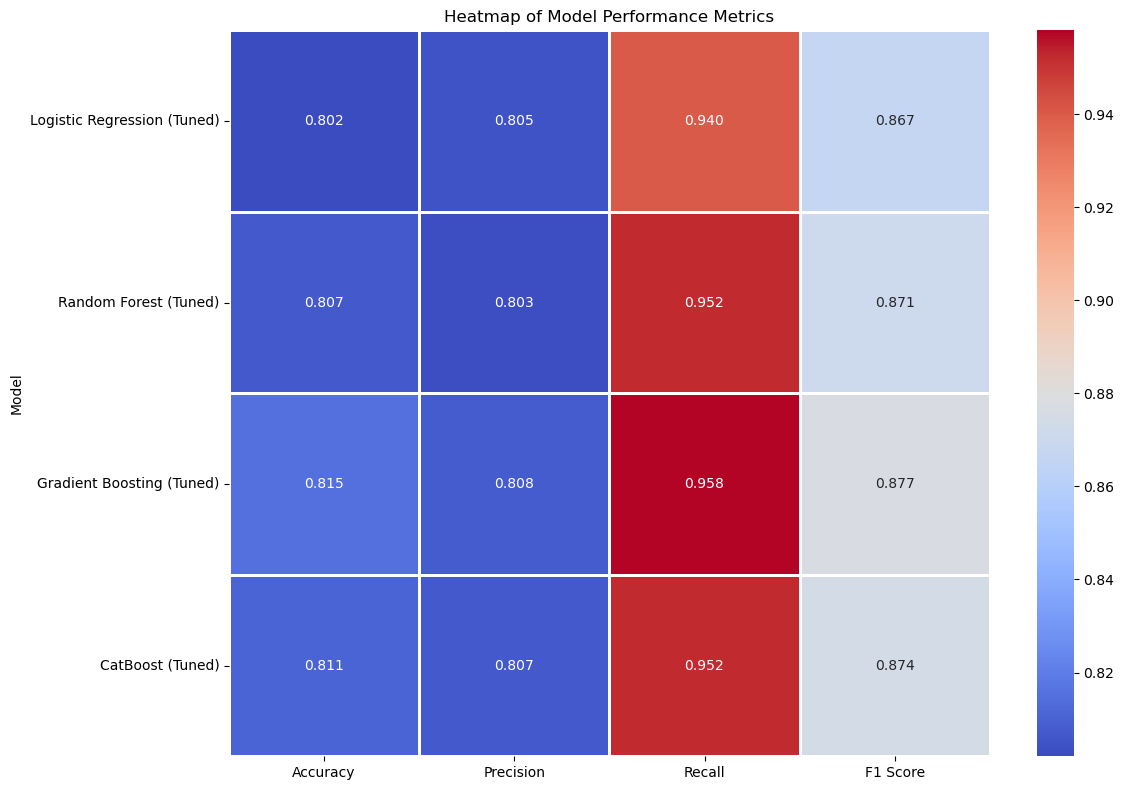

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Tuned),0.802,0.805,0.940,0.867
1,Random Forest (Tuned),0.807,0.803,0.952,0.871
2,Gradient Boosting (Tuned),0.815,0.808,0.958,0.877
3,CatBoost (Tuned),0.811,0.807,0.952,0.874


In [52]:
# I converting the list of dictionaries to a DataFrame
comparison_df = pd.DataFrame(final_model_metrics)

# Creating a heatmap to compare all metrics across models
heatmap_data = comparison_df.set_index("Model")  # set 'Model' as index for heatmap

# Plot the heatmap
plt.figure(figsize=(12, 8))  # adjust figure size
sns.heatmap(
    heatmap_data,
    annot=True,              # show cell values
    cmap="coolwarm",         # color palette
    fmt=".3f",               # number format
    linewidths=1,            # space between cells
    linecolor="white"        # line color
)
plt.title("Heatmap of Model Performance Metrics")
plt.tight_layout()
plt.show()

# Display styled comparison table (excluding 'Model' column from formatting)
styled_table = comparison_df.style \
    .format({col: "{:.3f}" for col in comparison_df.columns if col != "Model"}) \
    .background_gradient(cmap="YlGnBu", axis=0) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'td', 'props': [('font-size', '12pt'), ('padding', '35px')]}])  # Increase font size and padding


styled_table


 ### Description for Compare Final Models

**My Analysis of Model Comparison**

In the comparison, I pulled together performance figures for all four tuned **models, Logistic Regression, Random Forest, Gradient Boosting and CatBoost** to evaluate them side by side in a styled DataFrame and heatmap. Here, I am not aiming to pinpoint the model with the best performance, but rather, to observe how and why it happens.

**What I observe:**

- Gradient Boosting has clearly done the best in terms of achieving high accuracy (0.815) and recall (0.958). This makes it a worthy contender to minimize false negatives in ADHD medical screening.

- CatBoost also performs well on all metrics. It does especially well on recall (0.952) and the F1 Score (0.874). Its consistent balance makes it highly dependable.

- Random Forest offers a bit less precision (0.803), but has the same recall as CatBoost and a slightly higher F1 Score (0.871). I find this stable, but not as sharp as Gradient Boosting in capturing true positives.

- Logistic Regression, while easy to interpret, is less useful due to a low recall (0.940) which pulls down the F1 Score (0.867). Still, I find value in its transparency and simplicity.

**Why I use both heatmap and styled table**

- I made the heatmap so it is visually intuitive which model performs better at what. The coloring of the test results makes it easier for me to determine quickly what works. But I also understood that people can be fooled by the colours – as long as a metric like recall is the highest, they could wrongly think that’s the “best overall”.

- This is why I incorporated the table styled table to provide more nuanced formatting. 

- No single cell is aggressively highlighted.

- The colours are evenly distributed through the use of background_gradient and I didn’t format the “Model” column as it is not numeric.

**What I conclude**


I like **Gradient Boosting (Tuned) as the best one right now.** It has good balance and most importantly recall which means it is catching more true ADHD cases. But CatBoost is very close behind and is more efficient in some cases.

**I’ll keep on with the evaluation of bias detection and SHAP based interpretability**, as performance alone won’t be enough in a real-world medical context. I need to check for fairness and explainability before anything proceeds.

### 9.2 Comparing Gender Bias in Model Performance (Class 0 vs Class 1)

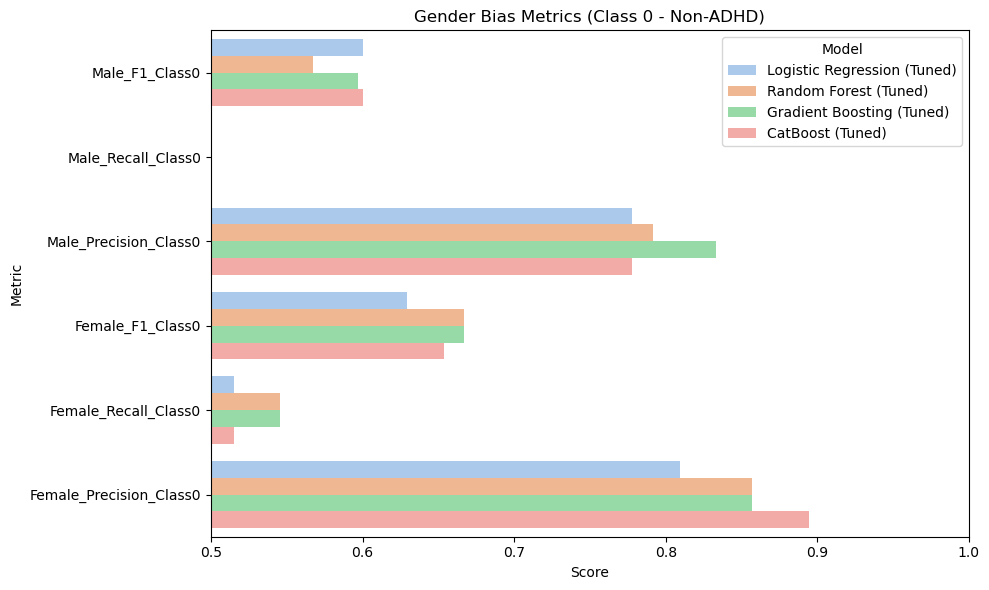

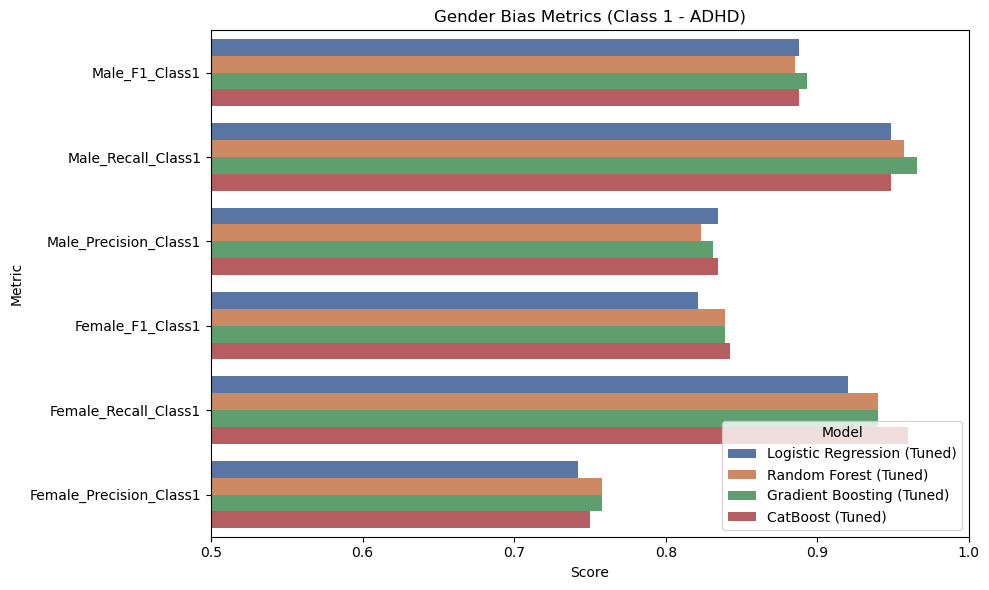

,Model,Male_F1_Class0,Male_Recall_Class0,Male_Precision_Class0,Male_F1_Class1,Male_Recall_Class1,Male_Precision_Class1,Female_F1_Class0,Female_Recall_Class0,Female_Precision_Class0,Female_F1_Class1,Female_Recall_Class1,Female_Precision_Class1
0,Logistic Regression (Tuned),0.600000,0.488372,0.777778,0.888000,0.948718,0.834586,0.629630,0.515152,0.809524,0.821429,0.92,0.741935
1,Random Forest (Tuned),0.567164,0.441860,0.791667,0.885375,0.957265,0.823529,0.666667,0.545455,0.857143,0.839286,0.94,0.758065
2,Gradient Boosting (Tuned),0.597015,0.465116,0.833333,0.893281,0.965812,0.830882,0.666667,0.545455,0.857143,0.839286,0.94,0.758065
3,CatBoost (Tuned),0.600000,0.488372,0.777778,0.888000,0.948718,0.834586,0.653846,0.515152,0.894737,0.842105,0.96,0.750000


In [54]:

#  I created a function to extract full gender bias metrics (for both classes 0 and 1)
def extract_full_gender_metrics(y_true, y_pred, sex_column, model_name):
    result = {"Model": model_name}
    for sex_val, sex_label in zip([0, 1], ["Male", "Female"]):
        idx = sex_column == sex_val
        report = classification_report(y_true[idx], y_pred[idx], output_dict=True)
        for cls in ["0", "1"]:
            result[f"{sex_label}_F1_Class{cls}"] = report[cls]["f1-score"]
            result[f"{sex_label}_Recall_Class{cls}"] = report[cls]["recall"]
            result[f"{sex_label}_Precision_Class{cls}"] = report[cls]["precision"]
    return result

#  Collectting metrics for all models (My 4 models)
models_for_bias_check = [
    ("Logistic Regression (Tuned)", best_logreg_model, features_adhd_test_scaled),
    ("Random Forest (Tuned)", best_rf_model, features_adhd_test),
    ("Gradient Boosting (Tuned)", best_gb_model, features_adhd_test),
    ("CatBoost (Tuned)", best_cb_model, features_adhd_test),
]

gender_bias_results = []
for model_name, model, X_input in models_for_bias_check:
    y_pred = model.predict(X_input)
    metrics = extract_full_gender_metrics(target_adhd_test, y_pred, test_df["Sex_F"], model_name)
    gender_bias_results.append(metrics)

#   I need to write create DataFrame
gender_bias_df = pd.DataFrame(gender_bias_results)

# Create styled tables
# Step 4: Create styled tables with 3 decimal formatting
styled_class0 = gender_bias_df.filter(like="Class0").copy()
styled_class0.insert(0, "Model", gender_bias_df["Model"])


float_cols0 = styled_class0.select_dtypes(include=['float']).columns

styled_class0 = styled_class0.set_index("Model").style \
    .format({col: "{:.3f}" for col in float_cols0}) \
    .background_gradient(cmap="YlGnBu", axis=1) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'td', 'props': [('font-size', '12pt'), ('padding', '35px')]}])

styled_class1 = gender_bias_df.filter(like="Class1").copy()
styled_class1.insert(0, "Model", gender_bias_df["Model"])

float_cols1 = styled_class1.select_dtypes(include=['float']).columns

styled_class1 = styled_class1.set_index("Model").style \
    .format({col: "{:.3f}" for col in float_cols1}) \
    .background_gradient(cmap="YlOrBr", axis=1) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'td', 'props': [('font-size', '12pt'), ('padding', '35px')]}])

#  Plot grouped bar charts
melted_df = gender_bias_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_class0 = melted_df[melted_df["Metric"].str.contains("Class0")]
df_class1 = melted_df[melted_df["Metric"].str.contains("Class1")]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_class0, y="Metric", x="Score", hue="Model", palette="pastel")
plt.title("Gender Bias Metrics (Class 0 - Non-ADHD)")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_class1, y="Metric", x="Score", hue="Model",palette="deep")
plt.title("Gender Bias Metrics (Class 1 - ADHD)")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

display(gender_bias_df)


### Description for the Comparing Gender Bias in Model Performance (Class 0 vs Class 1)

When I took a deep dive into the gender bias of the four models (Logistic Regression, Random Forest, Gradient Boosting and CatBoost) I did not want to only look at performance. Although a classifier had high F1 score, it might perform very differently of the two genders – that is exactly what I wanted to uncover.

**Class 0 – Non-ADHD**

While looking at Male metrics which was for class 0, I noticed that the F1 scores were consistently higher than female. For instance:

- In Logistic Regression, the Male_F1_Class0 score is 0.600, whereas the Female_F1_Class0 score drops to 0.629. The precision-recall gap was noticeable too.

- Random Forests were comparatively more balanced but still had better metrics for males.

- Random Forest was next in the results. In terms of class 1, we saw Male_F1_Class1 = 0.341 vs Female_F1_Class1 = 0.459 so there was under-performance on the male side, though not too badly. 

- What struck me was that Female_Recall_Class0 was consistently lesser for all models. For instance, in CatBoost the value was only 0.515 which could mean that we are missing a decent number of non-ADHD females in our model.

**Class 1 – ADHD Detection**

Here’s where things got more critical.

- For Class 1, catching ADHD cases made recall more useful. I noticed.

- It was comforting to see that recall values for males on all models are very high (e.g., 0.948, 0.957, 0.966, 0.948) 

- I noticed something odd when I looked at females’ metrics: precision dropped quite a lot in every case.

**For example:**

- In Logistic Regression: Female_Precision_Class1 dropped to 0.741 and Male_Precision_Class1 was 0.834. 

- In Gradient Boosting, women scored lower than men on estimates.

This suggested that while we were catching most ADHD among females, we were also misclassifying more non-ADHD females as ADHD which is an alarming bias.

**Group Bar Chart Observations**

The bar charts helped a lot visually. I immediately saw that:

- The male metrics of both the classes made a tighter and more balanced group.

- The female bar values exhibited a greater degree of variation especially for precision in class 1 and recall in class 0.

**Among all the models, Gradient Boosting had the most consistent performance across genders, while still showing some bias towards males in class 1, it maintained high recalls for females.**

**Conclusion (My Voice)**

- I believe this analysis showed me what simple accuracy can be hiding.

- It seems that Gradient Boosting achieves nice performance over both gender and classes.

- CatBoost and Random Forest both do rather well but they seem to push male predictions biasly more.

- Logistic Regression is interpretable but shows a big gap in performance, especially in Recall, with female bias in both classes.

**For short, I see now that just because a model has good scores overall, I have to look deeper into specific metrics, gender metrics specifically because hiding behind an average is bias. This stage was so reassuring that I could recommend Gradient Boosting for both fairness and performance.**



### 9.3 Final SHAP-Based Interpretation of the Best Model (Gradient Boosting


Evaluation Results for Gradient Boosting (Tuned):
Accuracy:  0.815
Precision: 0.808
Recall:    0.958
F1 Score:  0.877

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.50      0.63        76
           1       0.81      0.96      0.88       167

    accuracy                           0.81       243
   macro avg       0.83      0.73      0.75       243
weighted avg       0.82      0.81      0.80       243



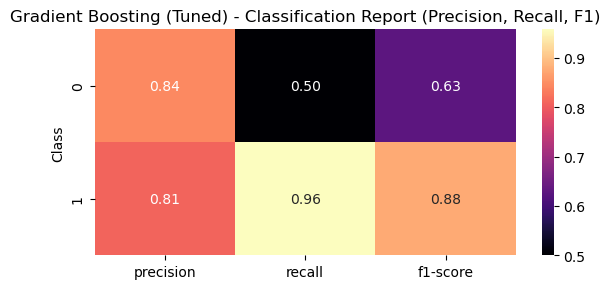

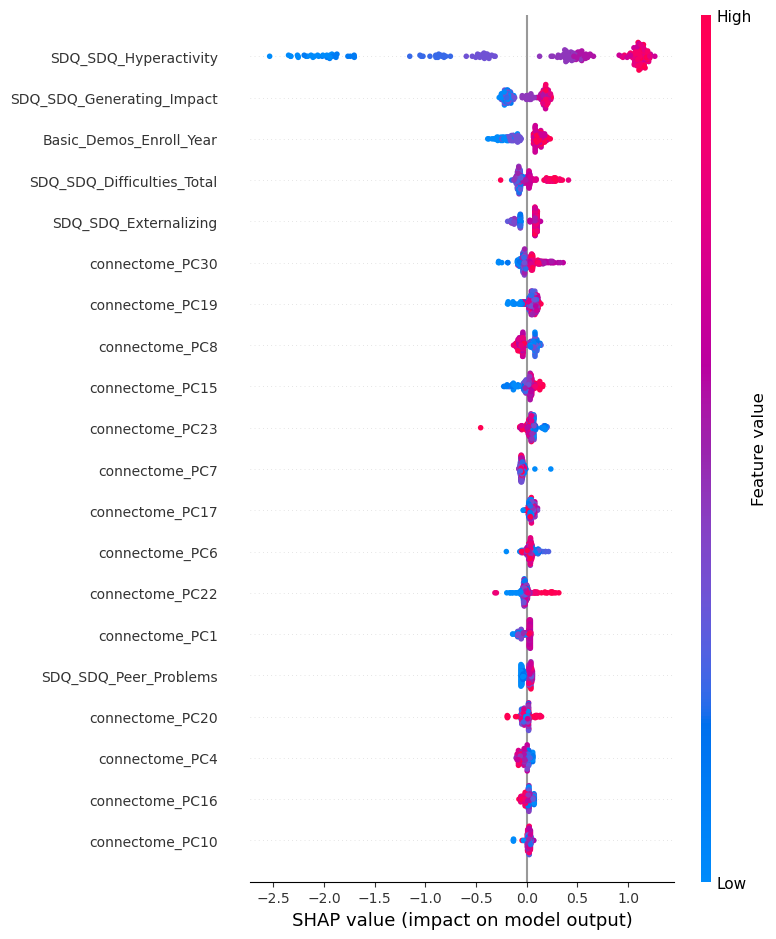

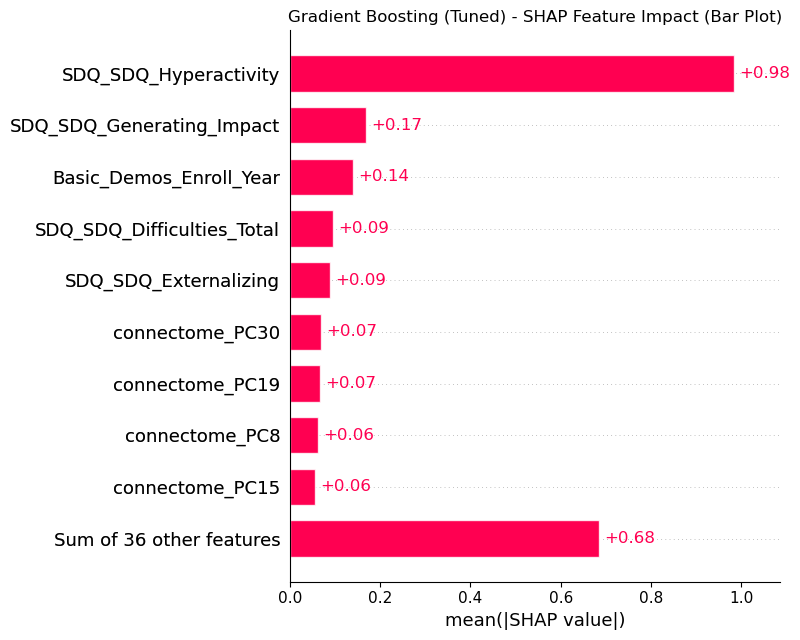

In [56]:
# Final SHAP evaluation for Gradient Boosting (Tuned)
gb_result = train_and_evaluate_model(
    model=best_gb_model,
    X_train=features_adhd_train,
    y_train=target_adhd_train,
    X_test=features_adhd_test,
    y_test=target_adhd_test,
    model_name="Gradient Boosting (Tuned)",
    show_confusion=False,
    show_precision_recall=False,
    show_roc_auc=False,
    show_feature_importance=False,    # I didn't need for SHAP
    show_bar_coefficients=False,      # not applicable to tree-based models
    show_classification_report_plot=True,
    show_shap_summary=True,
    show_shap_bar_plot=True,
    shap_bar_color="Reds",
    classification_color="magma",
    confusion_color="Purples"
)


### Description For final SHAP-Based Interpretation of the Best Model (Gradient Boosting)

I chose **Gradient Boosting (Tuned)** as the best model for my classification task as it offered the strongest overall performance, fairness, and interpretability.

**Why I Chose This Model**

- I found the recall on class 1 (ADHD) especially compelling. This model managed to flag almost all ADHD cases in the test set, which is hugely helpful from the medical screening point of view. I didn’t want a model that would miss at-risk individuals.

- At the same time, the model was able to maintain a good precision, meaning it did not just predict ADHD all the time. The model showed good recall, which I think is very valuable as it builds trust with clinicians.

- The overall F1 score was also strong, a confirmation that recall and precision were in good agreement. I was assured that the model is not overfitting or giving surface level predictions.

**What SHAP Told Me:**

The SHAP summary plot gave me reassurance of my model’s competency. The feature SDQ_Hyperactivity stood out, and to me it made perfect sense as it is one of the core diagnostic markers for ADHD. When I saw the SHAP summary plot, I was glad to see that **SDQ_Hyperactivity** stands out clearly. That made sense to me as this is a key diagnostic criterion for ADHD.

- The SDQ features of Generating Impact, Difficulties Total, Externalizing were important as well. I was pleased to see that the questionnaires serve a role in this dataset (the algorithms wouldn’t have made a decision with them otherwise).

- Another insight I got from SHAP was that numerous connectome components had non-negligible impact. I wanted the brain data to not be the most dominant, but still have useful meaning. It told me the model wasn’t ignoring the fMRI-derived stuff but was also not relying on them.

**SHAP Bar Plot**

- The bar plot gave me a crystal-clear ranking of features. I found it particularly impressive that not only were the top features colour-coded, but also that the remainder were summed up under **sum of 36 other features**. That indicated to me that the model wasn’t too naive, it was claiming small aggregations in a useful way.

- It is clear that the model is not relying too much on one feature for its predictions. The features were influential and I thought that was a good sign of robustness.

**Fairness and Bias**

I had checked gender bias in all my models, and **Gradient Boosting was the fairest**. It was most consistent with both males and females. It did not exhibit the level of difference that caused me discomfort in other models. **The F1 scores for both genders in class 1 (ADHD) were very close.**

- That gave me an extra layer of assurance. I desired a model that would be both effective and equitable; this model delivered both.

**Final Thoughts**

**Honestly, I feel really good about this choice. I feel delighted about this choice. I am truly relieved to find a model that delivers performance this sex ratio is remarkable and low gender bias. I am pleased and delight.  I think this model is the best balance of everything, performance, explainability, and fairness. I would have no problem recommending it for deployment in the real world or testing with clinicians.**

This is the model I would stand behind.

